In [ ]:
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Walmart_Sales.csv")


Mounted at /content/drive


In [ ]:
print(df.columns.tolist())

['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


In [ ]:
print(df.isnull().sum())

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


**1. Which stores generate the most revenue?**

  To identify which stores are the strongest performers, I calculated the average weekly sales per store across the entire dataset.

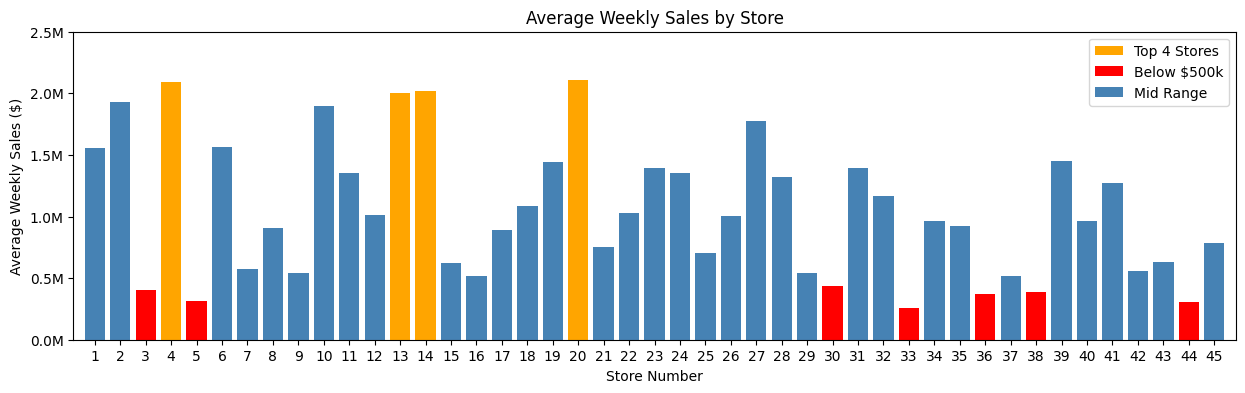

In [ ]:
storeSales = df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False)


def format_func(y, tick_number):
    return f'{float(y / 1000000)}M'


colors = ["orange" if i < 4 else "red" if storeSales.values[i] < 500000 else "steelblue" for i in range(len(storeSales))]

plt.figure(figsize=(15,4))
plt.bar(storeSales.index, storeSales.values, color=colors)
plt.title("Average Weekly Sales by Store")
plt.xlabel("Store Number")
plt.ylabel("Average Weekly Sales ($)")
plt.xticks(range(1,46))
plt.ylim(0,2500000)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_func))
plt.margins(x=0.01)
legend_elements = [Patch(facecolor='orange', label='Top 4 Stores'),Patch(facecolor='red', label='Below $500k'),Patch(facecolor='steelblue', label='Mid Range')]
plt.legend(handles=legend_elements)
plt.show()

On average, Stores 4, 13, 14 and 20 generate 2 million dollars of revenue each week leading to about 104 million dollars a year each, making them the top performers in Walmart network. Stores 3, 5, 30, 33, 36, 28 and 44 all generate on average less than 500k in weekly sales, suggesting they are in low traffic areas or have smaller store fronts. The performance difference between the top and bottom performers is significant, top performers generate nearly 5x the weakest store. This raises the question of whether underperforming locations should be evaluated for restructuring or additional investment.   

**2. Do holiday weeks significantly boost sales?**

To identify if holiday weeks boosted weekly sales, I calculated the average weekly sales for both weeks with holidays and weeks without holidays.

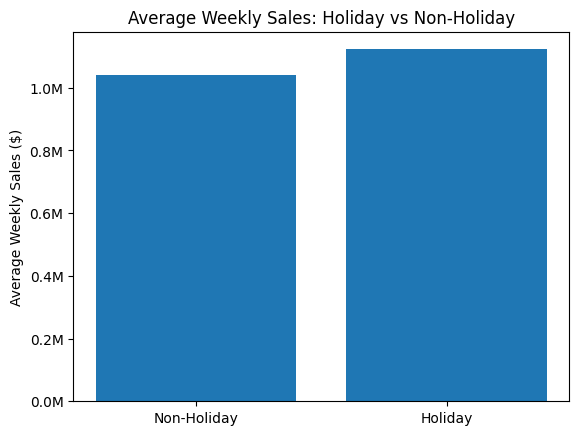

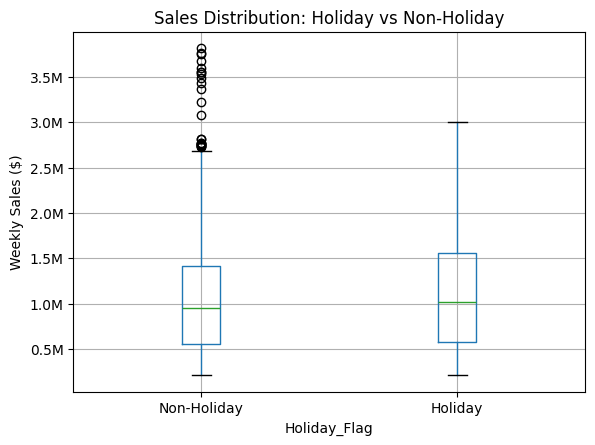

In [ ]:
storeSales= df.groupby("Holiday_Flag")["Weekly_Sales"].mean()

def format_func(y, tick_number):
    return f'{float(y / 1000000)}M'

plt.bar(storeSales.index,storeSales.values)
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xticks([0, 1], ["Non-Holiday", "Holiday"], rotation=0)
plt.ylabel("Average Weekly Sales ($)")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_func))
plt.show()

df.boxplot(column="Weekly_Sales", by="Holiday_Flag")
plt.title("Sales Distribution: Holiday vs Non-Holiday")
plt.suptitle("")
plt.xticks([1, 2], ["Non-Holiday", "Holiday"])
plt.ylabel("Weekly Sales ($)")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_func))
plt.show()

On average, holiday weeks generate roughly 10% more in weekly sales than non-holiday weeks. The distribution of non-holiday weeks contains several high-value outliers exceeding $2.5m, which may reflect weeks with significant events such as the Super Bowl or back-to-school shopping periods. Holiday weeks show greater variablitly overall, suggesting that not all holidays drive sales equally.

**3. Which time of year has the highest sales?**

To see which time of year has the highest sales, I took the sum of all the stores sales for each month over 3 years.

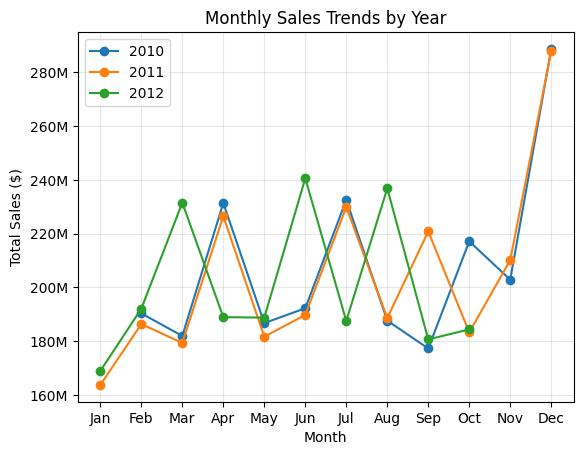

In [ ]:
df["Date"] = pd.to_datetime(df["Date"],format="%d-%m-%Y")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

monthlySales = df.groupby(["Year", "Month"])["Weekly_Sales"].sum().reset_index()

for year in monthlySales["Year"].unique():
    data = monthlySales[monthlySales["Year"] == year]
    plt.plot(data["Month"], data["Weekly_Sales"], marker="o", label=str(year))


def format_func(y, tick_number):
    return f'{int(y / 1000000)}M'

plt.title("Monthly Sales Trends by Year")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_func))
plt.show()

December consistently has the highest total sales across all 3 years, with 2011 peaking the highest at approximately $285M. This is expceted given the holiday shopping season. Sales tend to dip in January and show a moderate rise in spring, likely driven by seasonal shopping patterns. There is a noticable dip around August-September across all years before recovering into the holiday peak.

**4. Does temperature or fuel price affect weekly sales?**

To identify if temperature or fuel prices affect weekly sales, I created a scatter plot with a polynomial trend line.

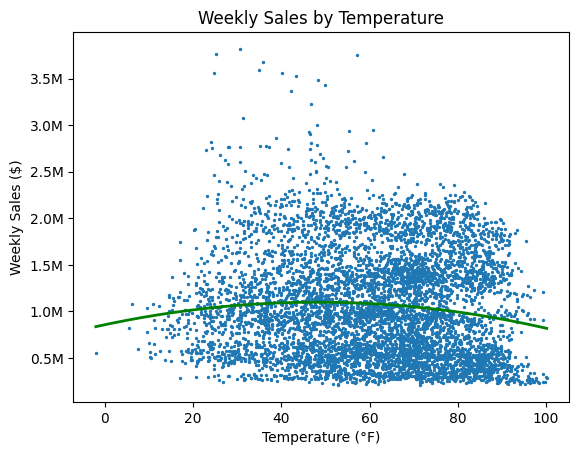

In [ ]:

x = df.Temperature
y = df.Weekly_Sales

def format_func(y, tick_number):
    return f'{float(y / 1000000)}M'

# Calculate the polynomial trend line (degree 2)
z = np.polyfit(x, y, 2)
p = np.poly1d(z)

# Plot the scatter plot and the polynomial trend line
plt.scatter(x, y, s=2)
x_smooth = np.linspace(x.min(), x.max(), 200)
plt.plot(x_smooth, p(x_smooth), "g-", linewidth=2)
plt.title("Weekly Sales by Temperature")
plt.xlabel("Temperature (°F)")
plt.ylabel("Weekly Sales ($)")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_func))
plt.show()

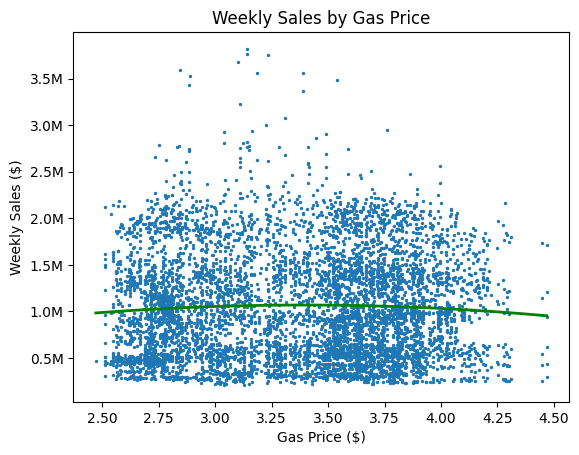

In [ ]:

x = df.Fuel_Price
y = df.Weekly_Sales

def format_func(y, tick_number):
    return f'{float(y / 1000000)}M'

# Calculate the polynomial trend line (degree 2)
z = np.polyfit(x, y, 2)
p = np.poly1d(z)

# Plot the scatter plot and the polynomial trend line
plt.scatter(x, y, s=2)
x_smooth = np.linspace(x.min(), x.max(), 200)
plt.plot(x_smooth, p(x_smooth), "g-", linewidth=2)
plt.title("Weekly Sales by Gas Price")
plt.xlabel("Gas Price ($)")
plt.ylabel("Weekly Sales ($)")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_func))
plt.show()

Weekly sales show a weak positive relationship with temperature, sales tend to be slightly higher in moderate temperatures (around 40-70°F) and drip at the extremes. The trend line is nearly flat, suggesting temperature is not a strong predictor of sales. Gas price similarly shows little to no relationship with weekly sales, with the trend line remaining almost completely flat across all price ranges. Both variables appear to have minimal impact on sales individually, tough they may still contribute when combined with other features in a model.

**5. Which stores are most consistent vs most volatile in sales?**

To identify which store are the most constistent vs most volatile in sales, I calculated the standard deviation of weekly sales of all the stores.

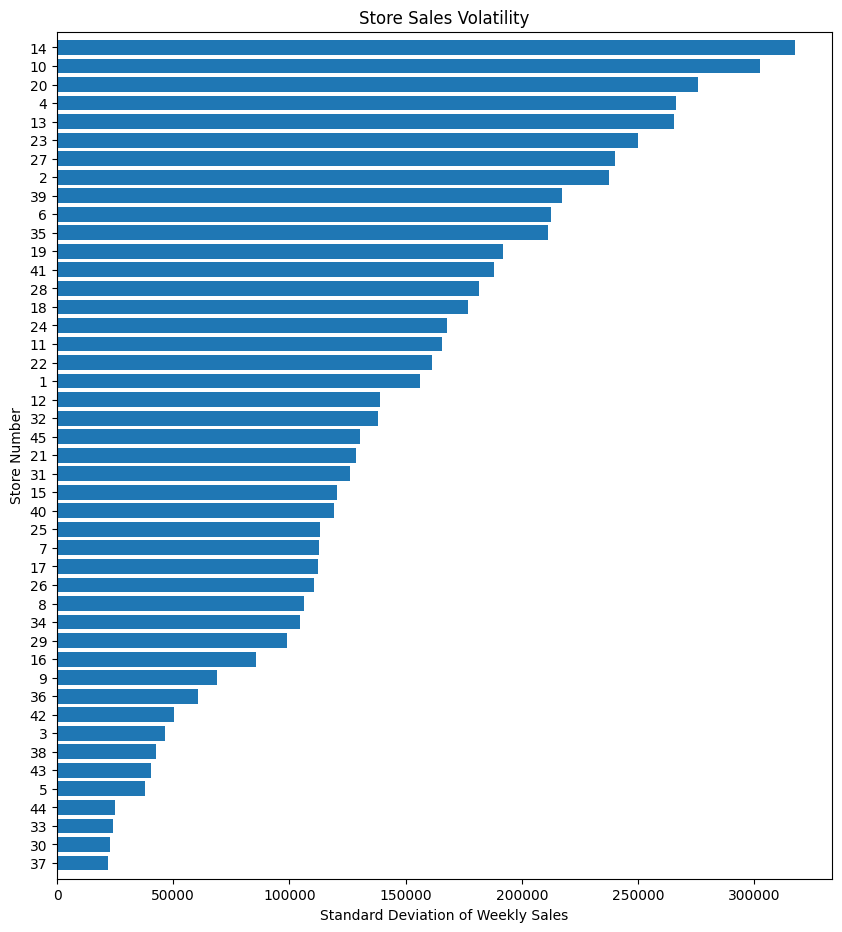

In [ ]:
storeVolatility = df.groupby("Store")["Weekly_Sales"].std().sort_values(ascending=True)

plt.figure(figsize=(10,11))
plt.barh(storeVolatility.index.astype(str),storeVolatility.values)
plt.xlabel("Standard Deviation of Weekly Sales")
plt.ylabel("Store Number")
plt.title("Store Sales Volatility")
plt.margins(y=0.01)
plt.show()


Stores 37, 30, 33 and 44 show the most consistent weekly sales, however they are also among the lowest performing stores overall. Stores 14, 10 and 20 are more volatile but tend to generate higher sales, suggesting that higher performiong stores may be sensitive to external facotrs scuh as seasonality or promotions. This raises the question of whether the volatiltiy in higher-performing stores is driven by holiday weeks, specific events, or other external factors.